In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


sns.set(style="whitegrid")


In [2]:
df=pd.read_csv("Climate Data.csv")

In [3]:
df.head()

,Y,M,D,T,TM,Tm,SLP,STP,H,PP,VV,V,VM,VG,FG,RA,SN,GR,TS,TR
0,1991,1,1,5.3,9.6,0.0,-,-,86,0,3.4,2.4,13,-,1,0,0,0,0,0
1,1991,1,2,2.6,6.4,0.0,-,-,88,0,3.7,4.1,11.1,-,1,0,0,0,0,0
2,1991,1,3,2.3,5.2,-1.0,-,-,87,0,2.6,2.0,9.4,-,1,0,0,0,0,0
3,1991,1,4,3.9,10.0,0.0,-,-,63,0,8.0,4.4,25.9,-,1,0,0,0,0,0
4,1991,1,5,2.9,10.4,-3.0,-,-,69,0,10.5,5.2,18.3,-,0,0,0,0,0,0


Objective 1: Understand the Dataset Structure

In [4]:
# Basic information
df.info()

# Statistical summary
df.describe()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       1826 non-null   int64  
 1   M       1826 non-null   int64  
 2   D       1826 non-null   int64  
 3   T       1826 non-null   float64
 4   TM      1826 non-null   float64
 5   Tm      1826 non-null   float64
 6   SLP     1826 non-null   object 
 7   STP     1826 non-null   object 
 8   H       1826 non-null   object 
 9   PP      1826 non-null   object 
 10  VV      1826 non-null   float64
 11  V       1826 non-null   float64
 12  VM      1826 non-null   object 
 13  VG      1826 non-null   object 
 14  FG      1826 non-null   int64  
 15  RA      1826 non-null   int64  
 16  SN      1826 non-null   int64  
 17  GR      1826 non-null   int64  
 18  TS      1826 non-null   int64  
 19  TR      1826 non-null   int64  
dtypes: float64(5), int64(9), object(6)
memory usage: 285.4+ KB


Y      0
M      0
D      0
T      0
TM     0
Tm     0
SLP    0
STP    0
H      0
PP     0
VV     0
V      0
VM     0
VG     0
FG     0
RA     0
SN     0
GR     0
TS     0
TR     0
dtype: int64

 Objective 2: Analyze Temperature Trends Over Time

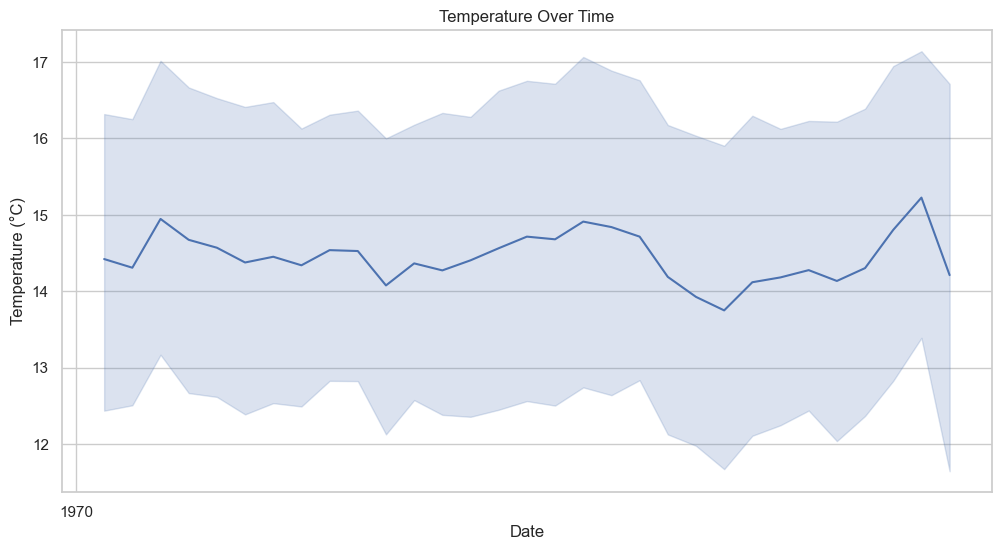

In [5]:
# Convert date column if needed
df['D'] = pd.to_datetime(df['D'])

# Plot temperature trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='D', y='T', data=df)
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()


Objective 3: Explore Seasonal Patterns (e.g., Rainfall by Month)

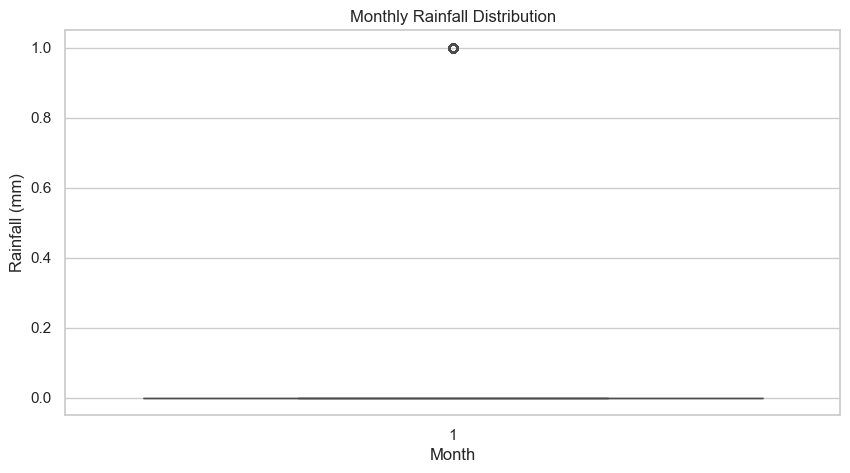

In [9]:
df['M'] = df['D'].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(x='M', y='RA', data=df)
plt.title("Monthly Rainfall Distribution")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()


 Objective 4: Correlation Between Climate Variables

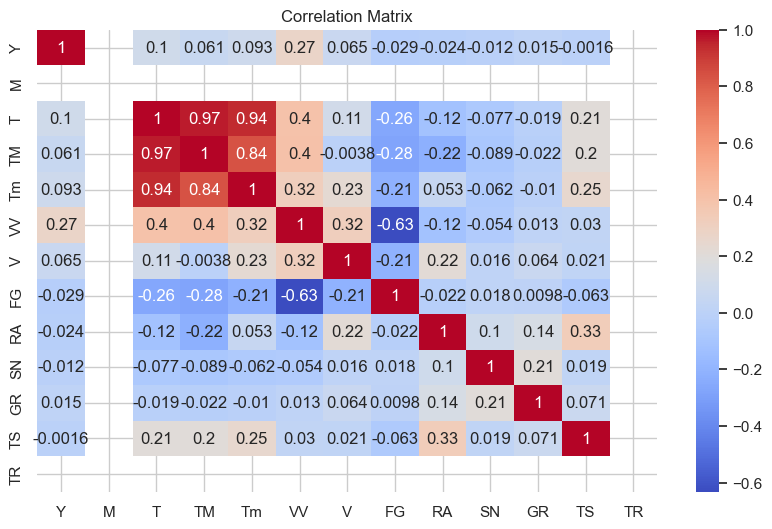

In [12]:
# Compute correlation matrix
corr = df.select_dtypes(include=[np.number]).corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Objective 5: Detect and Visualize Outliers

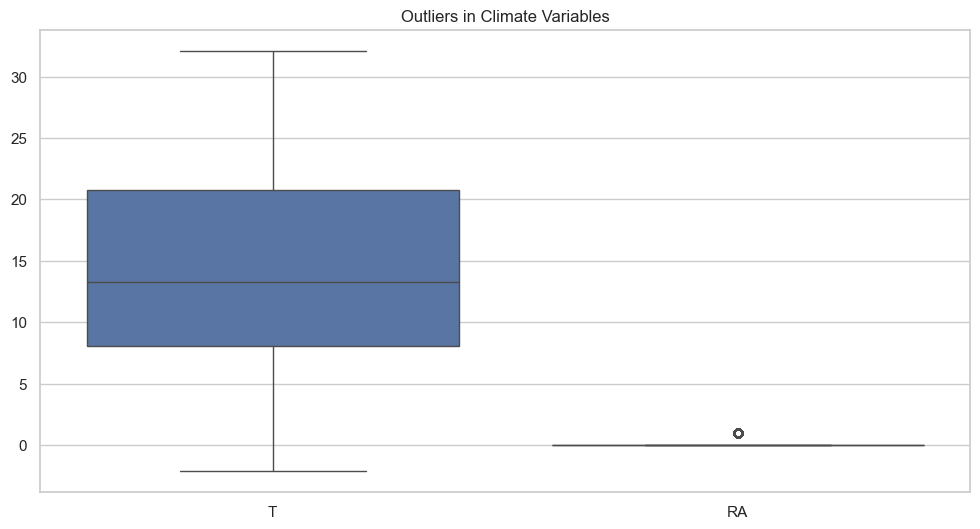

In [13]:
# Boxplot for key variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['T', 'H', 'RA']])
plt.title("Outliers in Climate Variables")
plt.show()


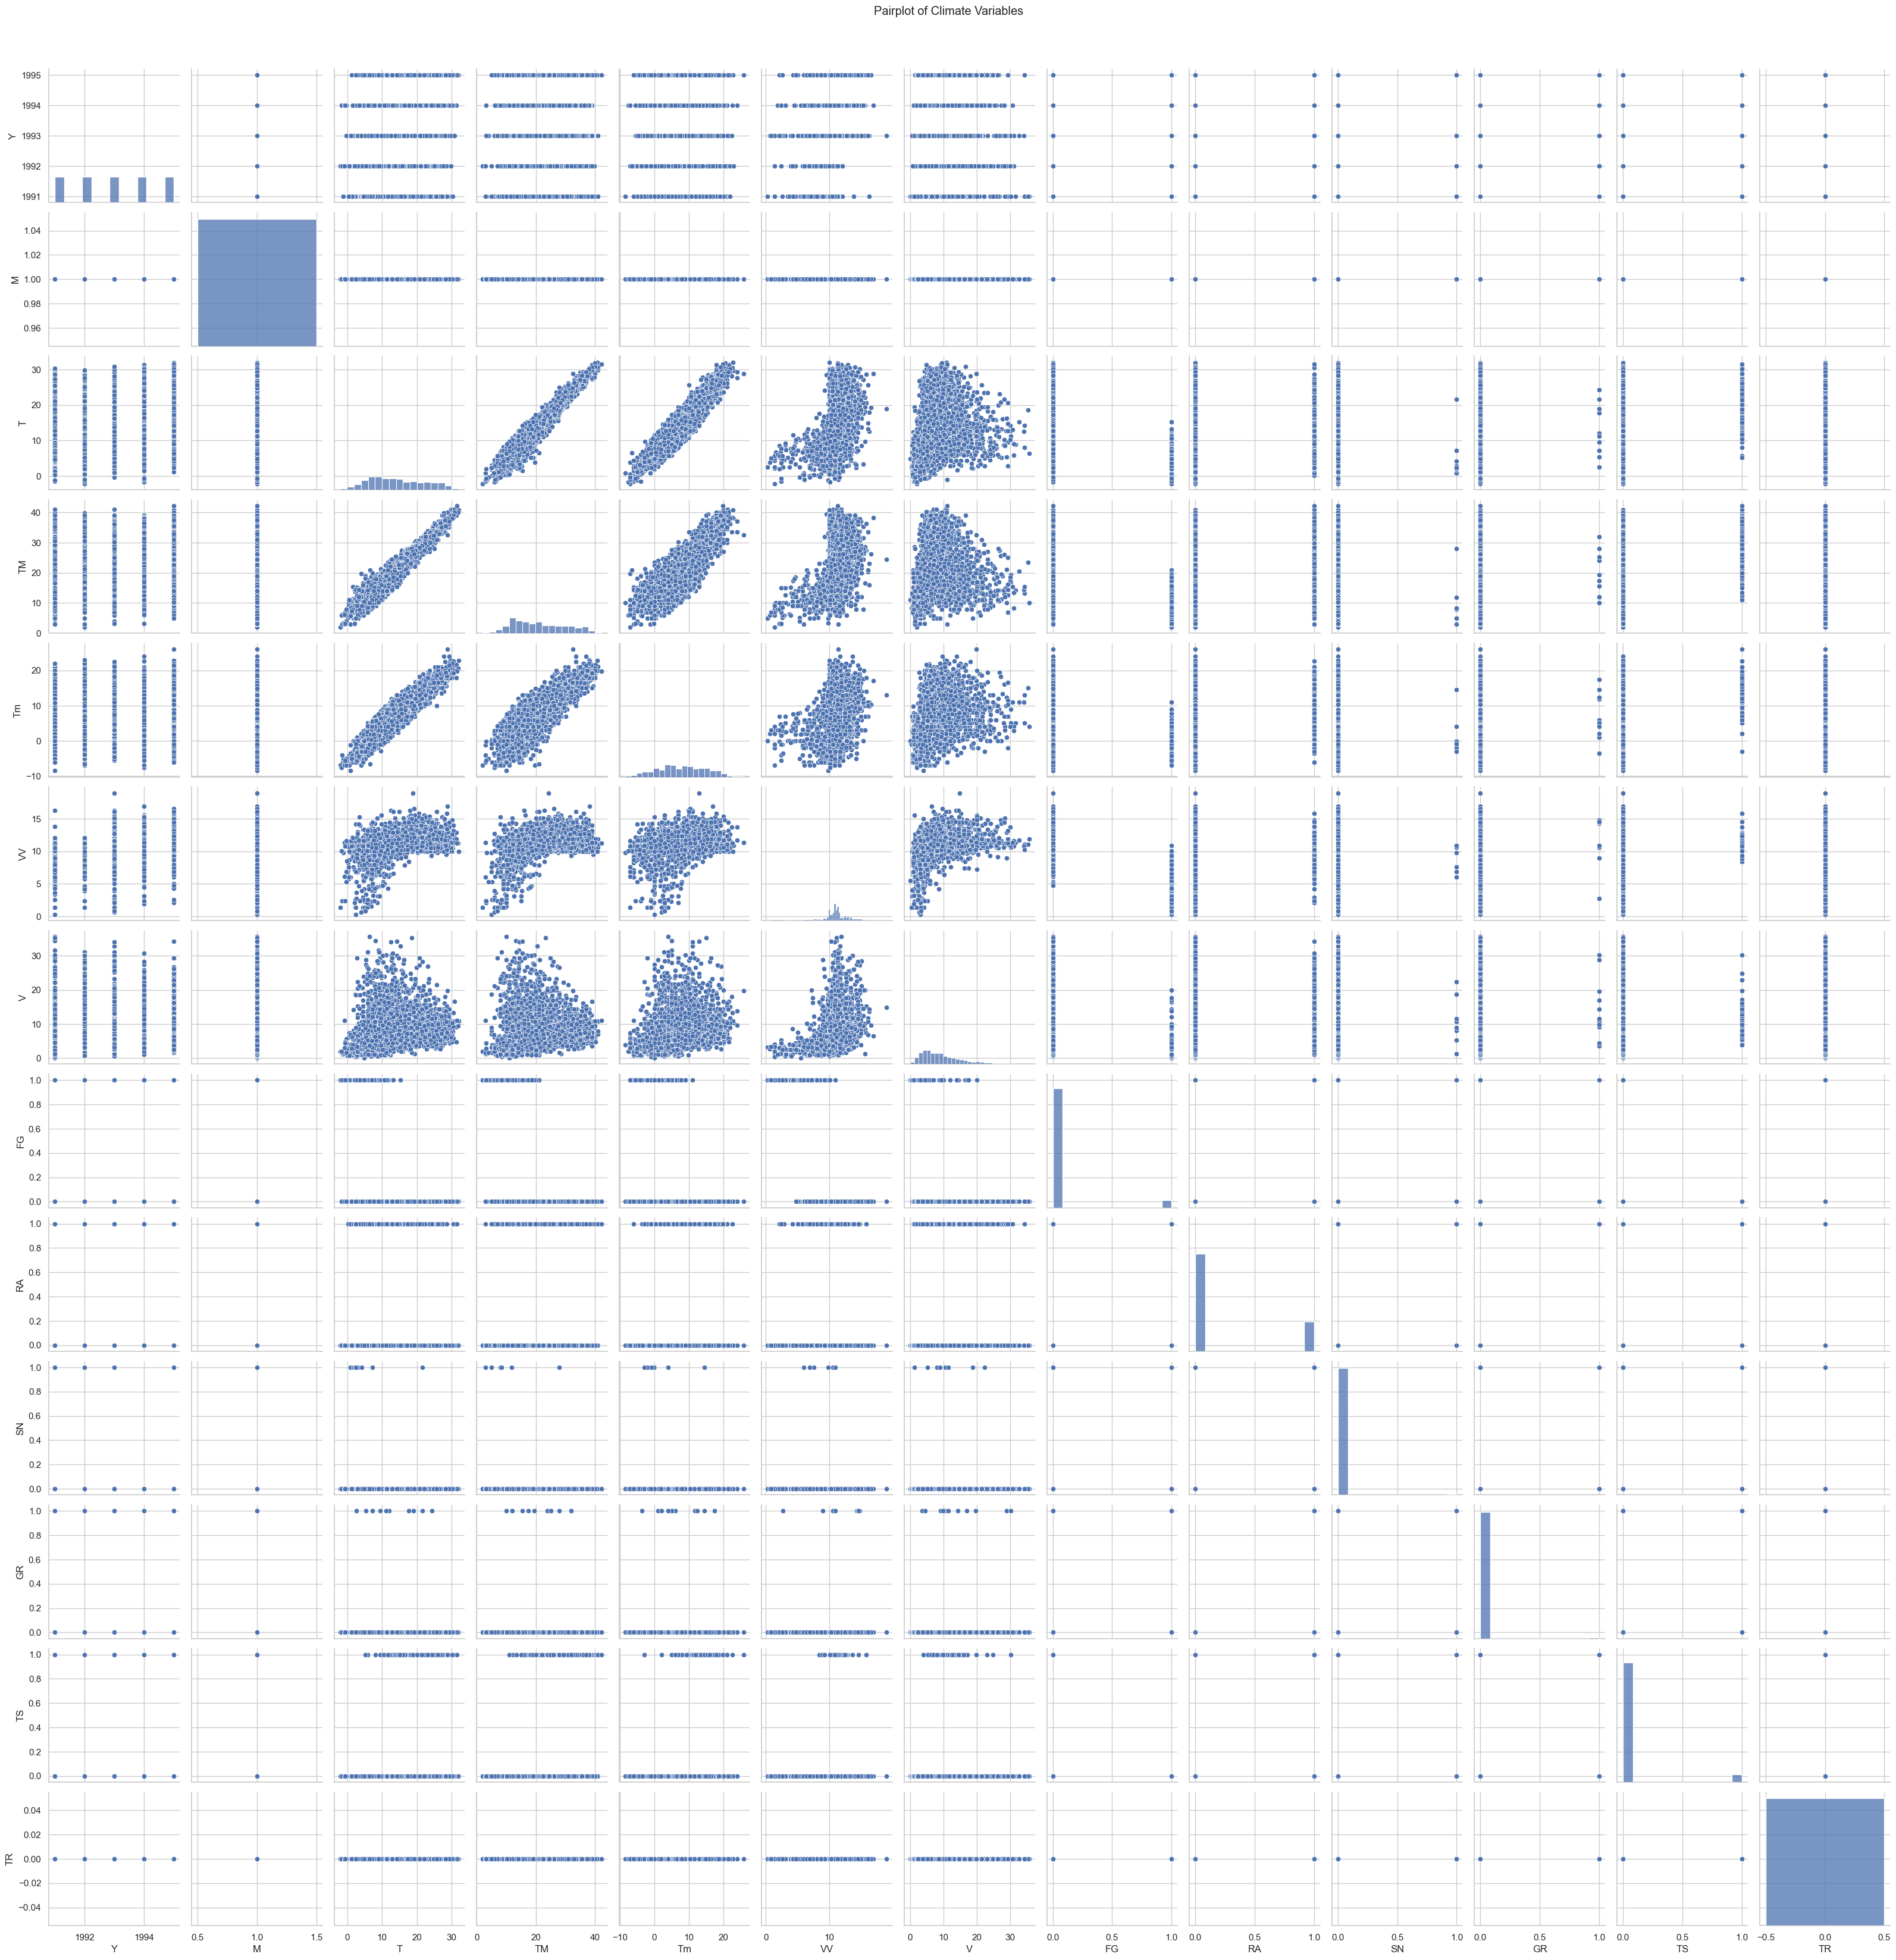

In [14]:
sns.pairplot(df.select_dtypes(include='number'))
plt.suptitle("Pairplot of Climate Variables", y=1.02)
plt.show()



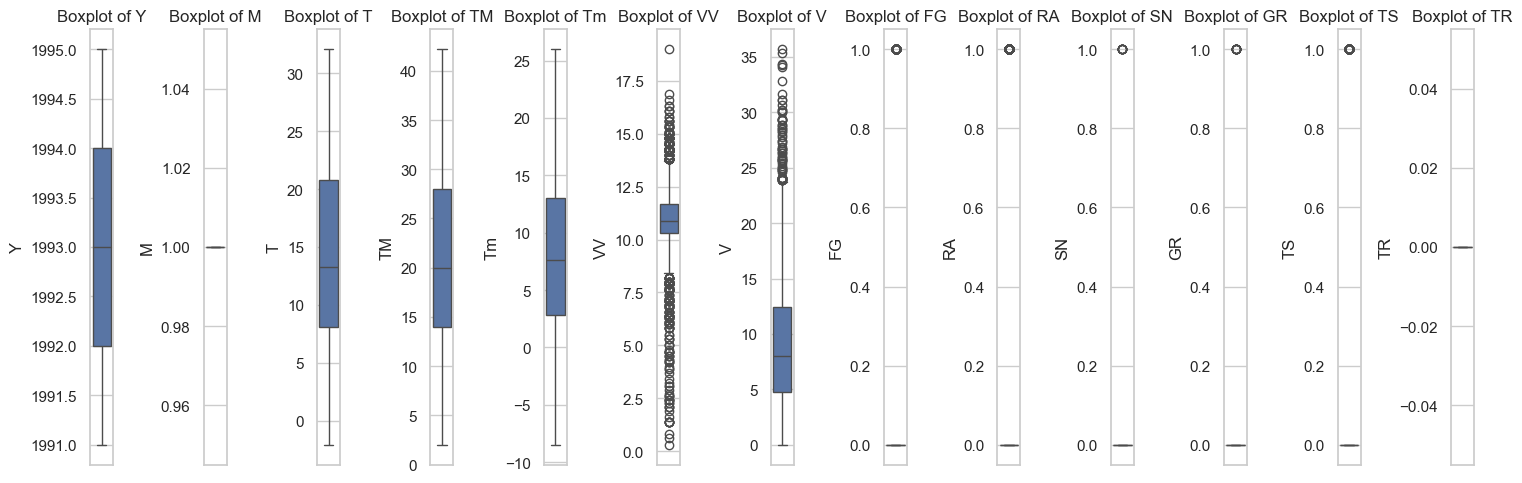

In [15]:
# Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(1, len(df.select_dtypes(include='number').columns), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()